<a href="https://colab.research.google.com/github/raisaaajose/Raisa-EDA-Project/blob/main/Raisa_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Loading the dataset
df = pd.read_csv("Auto.csv")

# 2. Handling Missing Data & Data Cleaning
print("Initial Missing values count per column:")
print(df.isnull().sum())

# Data Cleaning: Horsepower often has "?" in this dataset.
# Convert "?" to NaN, then convert column to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Fill missing horsepower with the median value
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Convert Origin and Cylinders to categorical
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin'] = df['origin'].map(origin_map)
df['cylinders'] = df['cylinders'].astype('category')

# 3. Data Transformation
# Create a new column: Weight per Horsepower
df['weight_per_hp'] = df['weight'] / df['horsepower']

# Create a final clean dataframe
df_clean = df.dropna(subset=['mpg'])

# 4. Basic Statistical Analysis
print("\n Basic Statistical Summary ")
print(df_clean.describe(include='all'))



Initial Missing values count per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

 Basic Statistical Summary 
               mpg  cylinders  displacement  horsepower       weight  \
count   392.000000      392.0    392.000000  392.000000   392.000000   
unique         NaN        5.0           NaN         NaN          NaN   
top            NaN        4.0           NaN         NaN          NaN   
freq           NaN      199.0           NaN         NaN          NaN   
mean     23.445918        NaN    194.411990  104.469388  2977.584184   
std       7.805007        NaN    104.644004   38.491160   849.402560   
min       9.000000        NaN     68.000000   46.000000  1613.000000   
25%      17.000000        NaN    105.000000   75.000000  2225.250000   
50%      22.750000        NaN    151.000000   93.500000  2803.500000   
75%      29.000000        NaN    27

/tmp/ipykernel_695/892159690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='origin', palette="viridis", ax=axes[0,1])


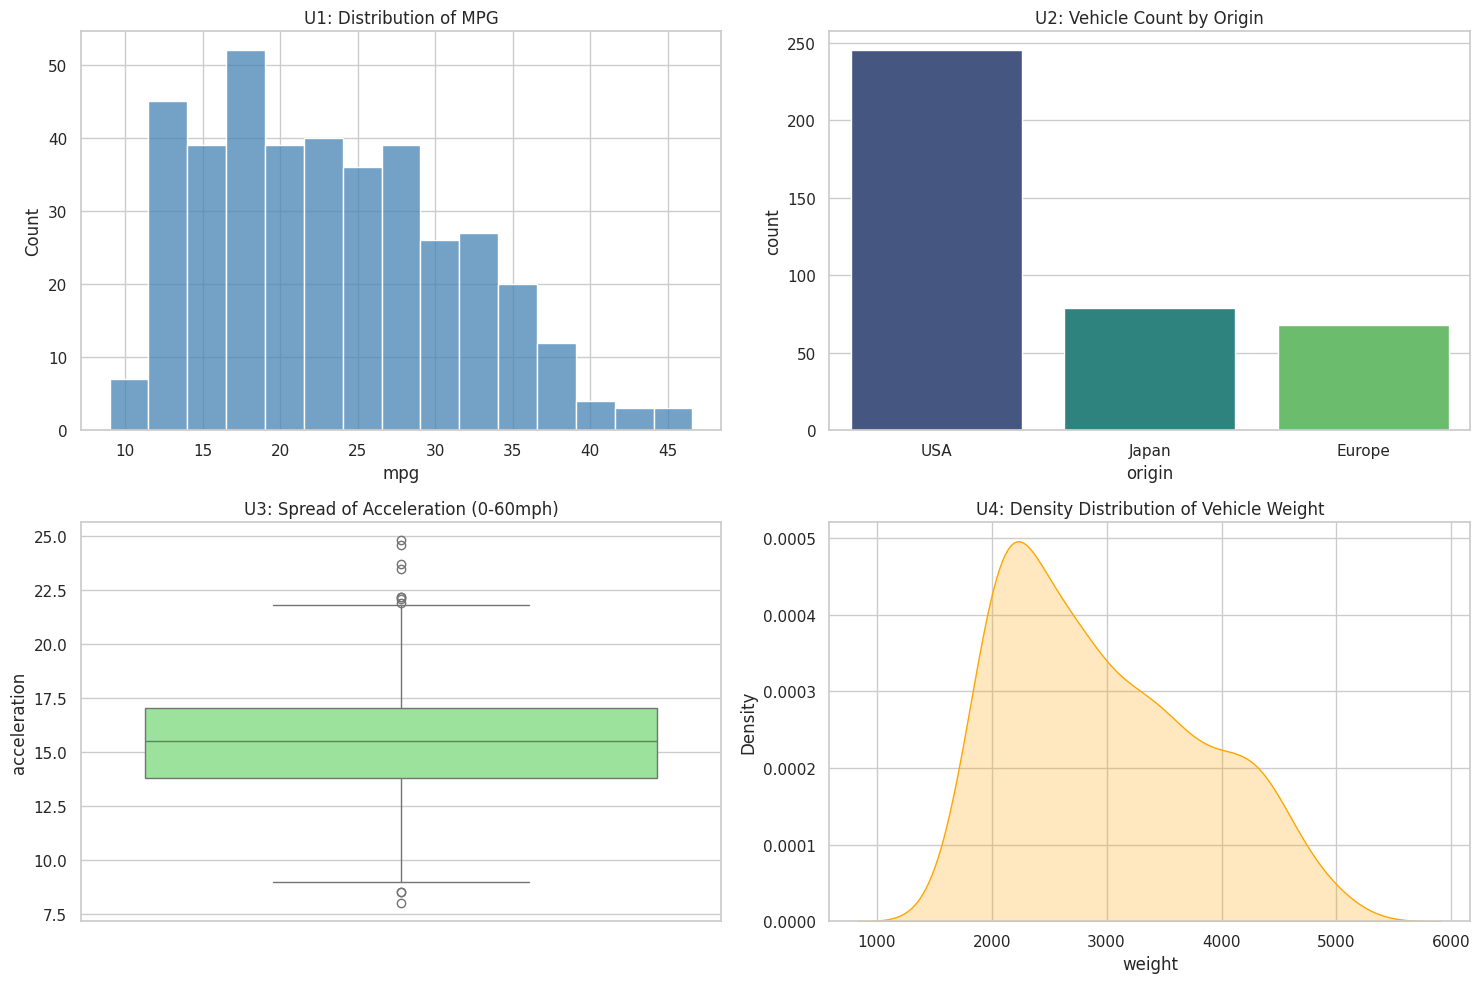

In [3]:
# 5. Univariate Analysis (4 Visualizations)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Viz 1: Distribution of MPG
sns.histplot(df_clean['mpg'], bins=15, color="steelblue", kde=False, ax=axes[0,0])
axes[0,0].set_title("U1: Distribution of MPG")

# Viz 2: Count of Cars by Origin
sns.countplot(data=df_clean, x='origin', palette="viridis", ax=axes[0,1])
axes[0,1].set_title("U2: Vehicle Count by Origin")

# Viz 3: Spread of Acceleration
sns.boxplot(y=df_clean['acceleration'], color="lightgreen", ax=axes[1,0])
axes[1,0].set_title("U3: Spread of Acceleration (0-60mph)")

# Viz 4: Density of Vehicle Weight
sns.kdeplot(df_clean['weight'], fill=True, color="orange", ax=axes[1,1])
axes[1,1].set_title("U4: Density Distribution of Vehicle Weight")

plt.tight_layout()
plt.show()

/tmp/ipykernel_695/3200630485.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='origin', y='mpg', palette="Set2", ax=axes[0,1])
/tmp/ipykernel_695/3200630485.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='cylinders', y='mpg', palette="Pastel1", ax=axes[1,1])


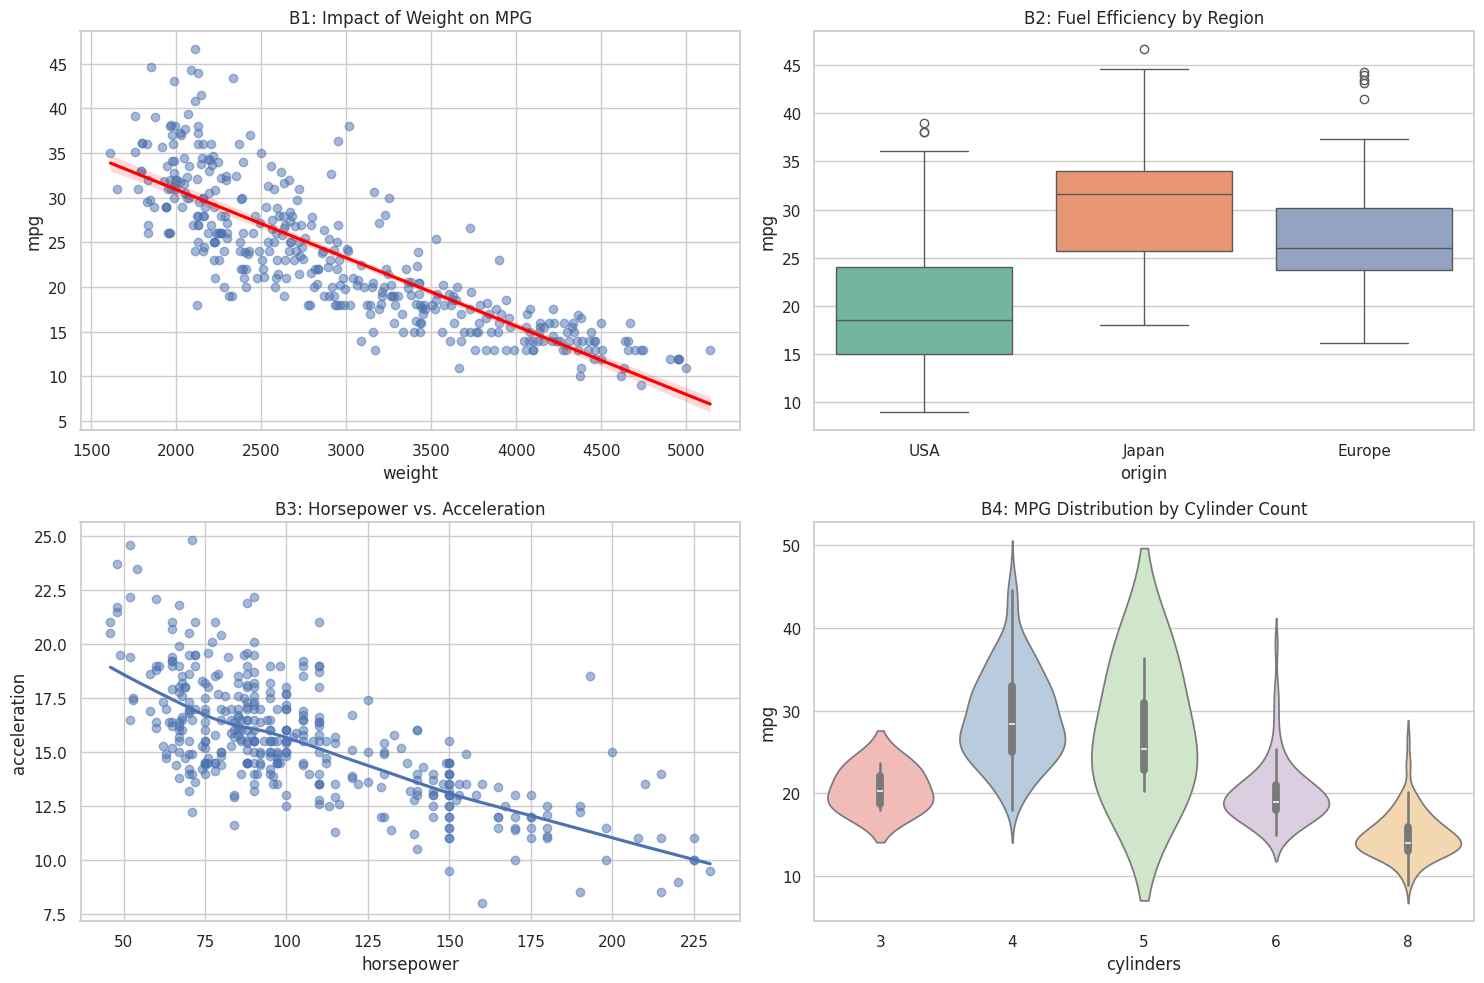

In [4]:
# 6. Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Viz 1: MPG vs Weight (Scatter Plot + Regression Line)
sns.regplot(data=df_clean, x='weight', y='mpg', scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[0,0])
axes[0,0].set_title("B1: Impact of Weight on MPG")

# Viz 2: MPG by Origin (Boxplot)
sns.boxplot(data=df_clean, x='origin', y='mpg', palette="Set2", ax=axes[0,1])
axes[0,1].set_title("B2: Fuel Efficiency by Region")

# Viz 3: Horsepower vs Acceleration (Scatter Plot + Trend)
sns.regplot(data=df_clean, x='horsepower', y='acceleration', lowess=True, scatter_kws={'alpha':0.5}, ax=axes[1,0])
axes[1,0].set_title("B3: Horsepower vs. Acceleration")

# Viz 4: MPG by Cylinder Count (Violin Plot)
sns.violinplot(data=df_clean, x='cylinders', y='mpg', palette="Pastel1", ax=axes[1,1])
axes[1,1].set_title("B4: MPG Distribution by Cylinder Count")

plt.tight_layout()
plt.show()

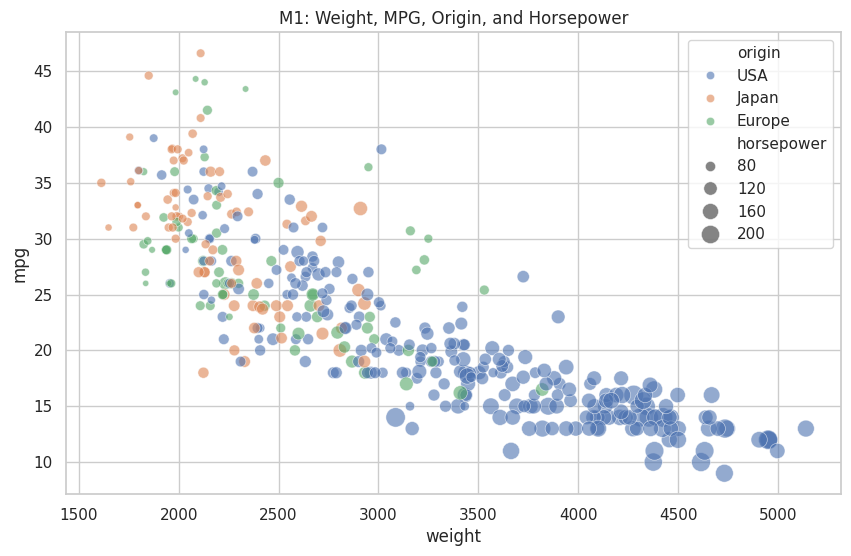

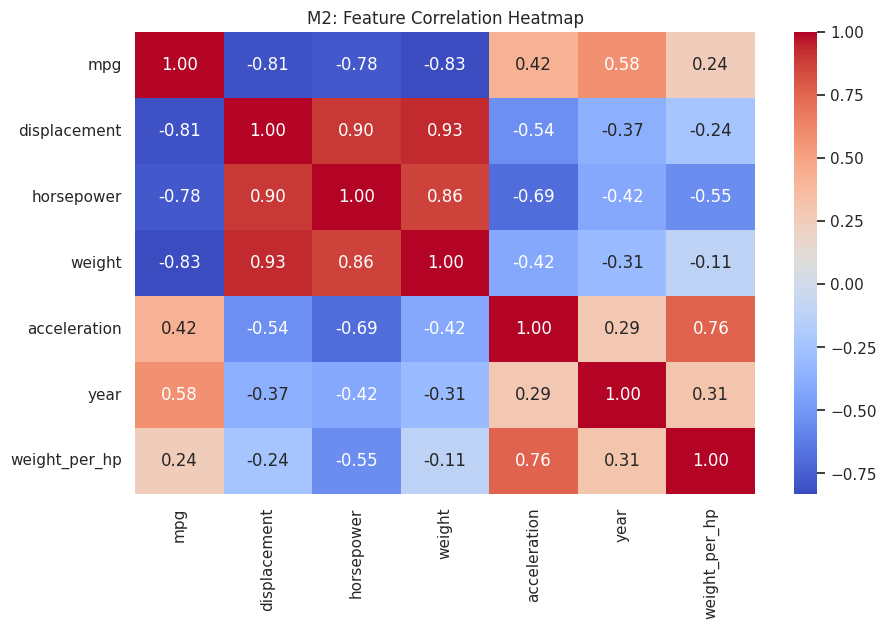

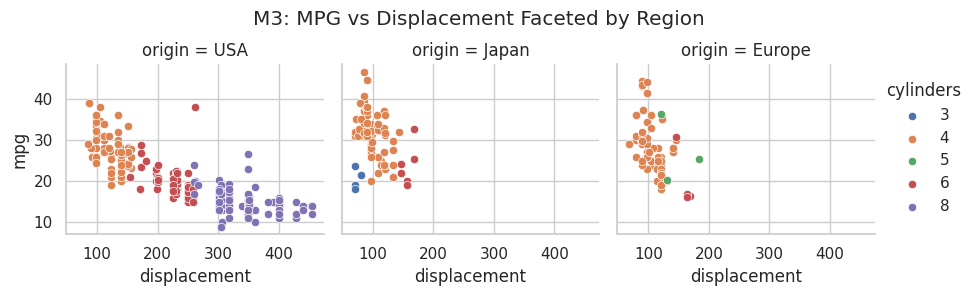

/tmp/ipykernel_695/1992465187.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df_clean, x="cylinders", y="mpg", col="origin", kind="box", palette="muted", height=4, aspect=1)


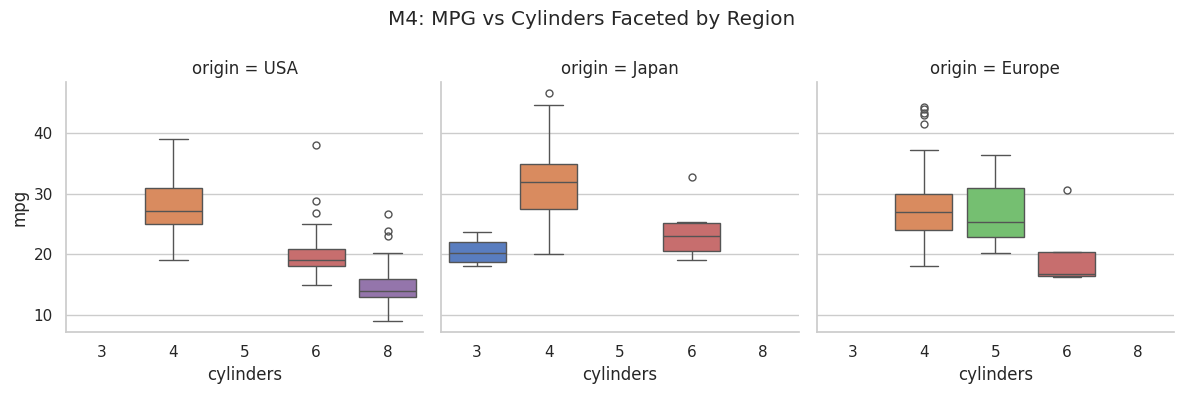

In [5]:
# 7. Multivariate Analysis

# Viz 1: Weight vs MPG colored by Origin and sized by HP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='weight', y='mpg', hue='origin', size='horsepower', alpha=0.6, sizes=(20, 200))
plt.title("M1: Weight, MPG, Origin, and Horsepower")
plt.show()

# Viz 2: Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("M2: Feature Correlation Heatmap")
plt.show()

# Viz 3: Faceted Scatter Plot (MPG vs Displacement faceted by Origin)
g = sns.FacetGrid(df_clean, col="origin", hue="cylinders")
g.map(sns.scatterplot, "displacement", "mpg")
g.add_legend()
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("M3: MPG vs Displacement Faceted by Region")
plt.show()

# Viz 4: Faceted Boxplot (MPG vs Cylinders faceted by Origin)
sns.catplot(data=df_clean, x="cylinders", y="mpg", col="origin", kind="box", palette="muted", height=4, aspect=1)
plt.subplots_adjust(top=0.8)
plt.gcf().suptitle("M4: MPG vs Cylinders Faceted by Region")
plt.show()